# Predicting Average House Prices in Madrid Neighbourhoods Using Socioeconomic Indicators

## Overall Project Aim:
To develop and evaluate a machine learning model that uses 2025 socioeconomic indicators to predict average housing prices across Madrid neighbourhoods.

## Contents:

  ## 4. Exploratory Data Analysis (EDA) and Visualisation
  ## 5. Data Prepatation
  ## 6. Train-test Split
  ## 7. Model Development
  ## 8. Predictions and Interpretations 
  ## 9. Model Evaluation
  ## 10. Improvements

### Introduction 

Following data cleaning and preparation, the socioeconomic indicator and average housing price datasets for Madrid's 130 residential neighbourhoods were ready to be merged. Following the merge and final checks, the following steps were carried out:

- Explored the distributions of selected socioeconomic indicators and their relationships with housing prices.
- Defined the model's features and target variable.
- Split the data 80:20 into training and test sets.
- Built and trained a linear regression model to predict average neighbourhood housing prices.
- Evaluated the model using Mean Absolute Error (MAE), Mean Squared Error (MSE) and R².
- Interpreted the model's performance, including comparing predicted and actual housing prices.

Finally, the model's limitations and potential improvements were considered.

### Import Libraries 

In [1]:
# Import the Pandas library for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for creating basic charts and graphs
import matplotlib.pyplot as plt

# Import Seaborn for creating attractive statistical visualisations
import seaborn as sns

# Import Train-test Split to divide the dataset 
from sklearn.model_selection import train_test_split

# Import Linear Regression to implement the LR model
from sklearn.linear_model import LinearRegression

# Import test metrics to test and evaluate the LR model's prediction ability
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

### Load prepared datasets

In [2]:
features = pd.read_csv("../data/features_2025_prepared.csv")
target = pd.read_csv("../data/prices_2025_prepared.csv")

### Intitial Inspection

In [3]:
# Features: preview first five rows
features.head()

,neighbourhood_name,average_population_age,population_density,ageing_rate,average_disposable_income_per_person,average_annual_net_household_income,average_household_size,registered_unemployment_rate,population_growth_rate,social_welfare_and_equality_vulnerability_index,economy_and_employment_vulnerability_index,education_and_culture_vulnerability_index,urban_environment_and_mobility_vulnerability_index,health_vulnerability_index,percentage_residential_properties,percentage_of_population_25_plus_either_higher_ed_or_technical
0,Abrantes,42.526992,217.812860,16.763353,12515.0,33622.23,2.854973,4.75,-4.858374,7.435267,10.679521,13.155908,5.137581,6.517903,6.094808,21.360868
1,Acacias,47.952118,340.469536,26.544208,24444.0,52933.24,2.269051,3.36,-1.119321,6.838957,4.984878,6.820111,6.257348,6.147339,2.069475,56.354576
2,Adelfas,45.799606,298.720350,23.095926,24543.0,53793.35,2.332925,2.83,-1.019626,6.368324,5.089996,3.952608,6.197105,6.897478,1.444043,56.869978
3,Alameda de Osuna,46.594390,98.759415,26.510692,24417.0,60255.00,2.601780,2.43,-0.960566,7.385542,4.319867,3.691305,5.384812,6.682053,2.851324,55.965134
4,Almagro,46.356893,213.775456,24.439776,33425.0,78233.57,2.328984,2.08,-2.912966,8.209531,5.104565,5.823923,8.552990,8.523912,0.127173,67.589718


In [4]:
# Features: check the number of rows and columns
features.shape

(130, 16)

In [5]:
# Target: preview first five rows
target.head()

,neighbourhood_name,mean_average_price_euros_per_m2
0,Abrantes,2912.90
1,Acacias,5736.45
2,Adelfas,5741.86
3,Alameda de Osuna,5052.01
4,Almagro,10795.41


In [6]:
# Target: check the number of rows and columns

target.shape

(130, 2)

### Merge datasets

In [7]:
# Perform inner merge on datasets 
madrid_2025=pd.merge(features, target, how='inner', on='neighbourhood_name')

In [8]:
# Preview first 5 rows of the merged dataset
madrid_2025.head()

,neighbourhood_name,average_population_age,population_density,ageing_rate,average_disposable_income_per_person,average_annual_net_household_income,average_household_size,registered_unemployment_rate,population_growth_rate,social_welfare_and_equality_vulnerability_index,economy_and_employment_vulnerability_index,education_and_culture_vulnerability_index,urban_environment_and_mobility_vulnerability_index,health_vulnerability_index,percentage_residential_properties,percentage_of_population_25_plus_either_higher_ed_or_technical,mean_average_price_euros_per_m2
0,Abrantes,42.526992,217.812860,16.763353,12515.0,33622.23,2.854973,4.75,-4.858374,7.435267,10.679521,13.155908,5.137581,6.517903,6.094808,21.360868,2912.90
1,Acacias,47.952118,340.469536,26.544208,24444.0,52933.24,2.269051,3.36,-1.119321,6.838957,4.984878,6.820111,6.257348,6.147339,2.069475,56.354576,5736.45
2,Adelfas,45.799606,298.720350,23.095926,24543.0,53793.35,2.332925,2.83,-1.019626,6.368324,5.089996,3.952608,6.197105,6.897478,1.444043,56.869978,5741.86
3,Alameda de Osuna,46.594390,98.759415,26.510692,24417.0,60255.00,2.601780,2.43,-0.960566,7.385542,4.319867,3.691305,5.384812,6.682053,2.851324,55.965134,5052.01
4,Almagro,46.356893,213.775456,24.439776,33425.0,78233.57,2.328984,2.08,-2.912966,8.209531,5.104565,5.823923,8.552990,8.523912,0.127173,67.589718,10795.41


In [9]:
# Checking dimensions
madrid_2025.shape

(129, 17)

In [10]:
# Outer merge
checking_madrid_2025=pd.merge(features, target, how='outer', on='neighbourhood_name')

In [11]:
# Preview first 5 records of outer merged dataset
checking_madrid_2025.head()

,neighbourhood_name,average_population_age,population_density,ageing_rate,average_disposable_income_per_person,average_annual_net_household_income,average_household_size,registered_unemployment_rate,population_growth_rate,social_welfare_and_equality_vulnerability_index,economy_and_employment_vulnerability_index,education_and_culture_vulnerability_index,urban_environment_and_mobility_vulnerability_index,health_vulnerability_index,percentage_residential_properties,percentage_of_population_25_plus_either_higher_ed_or_technical,mean_average_price_euros_per_m2
0,Abrantes,42.526992,217.812860,16.763353,12515.0,33622.23,2.854973,4.75,-4.858374,7.435267,10.679521,13.155908,5.137581,6.517903,6.094808,21.360868,2912.90
1,Acacias,47.952118,340.469536,26.544208,24444.0,52933.24,2.269051,3.36,-1.119321,6.838957,4.984878,6.820111,6.257348,6.147339,2.069475,56.354576,5736.45
2,Adelfas,45.799606,298.720350,23.095926,24543.0,53793.35,2.332925,2.83,-1.019626,6.368324,5.089996,3.952608,6.197105,6.897478,1.444043,56.869978,5741.86
3,Alameda de Osuna,46.594390,98.759415,26.510692,24417.0,60255.00,2.601780,2.43,-0.960566,7.385542,4.319867,3.691305,5.384812,6.682053,2.851324,55.965134,5052.01
4,Almagro,46.356893,213.775456,24.439776,33425.0,78233.57,2.328984,2.08,-2.912966,8.209531,5.104565,5.823923,8.552990,8.523912,0.127173,67.589718,10795.41


In [12]:
# Check dimensions of outer merged dataset
checking_madrid_2025.shape

(131, 17)

### Observations 

Following an inner merge using neighbourhood_name as the common key, perfect alignment between the datasets would result in 130 rows and 17 columns. However, the merged dataset contained one fewer row than expected. An outer merge was therefore performed to identify any discrepancies, as it retains observations from both datasets even where the common key does not match.

In [13]:
# Check total null values of outer merged dataset
checking_madrid_2025.isnull().sum()

neighbourhood_name                                                0
average_population_age                                            1
population_density                                                1
ageing_rate                                                       1
average_disposable_income_per_person                              1
average_annual_net_household_income                               1
average_household_size                                            1
registered_unemployment_rate                                      1
population_growth_rate                                            1
social_welfare_and_equality_vulnerability_index                   1
economy_and_employment_vulnerability_index                        1
education_and_culture_vulnerability_index                         1
urban_environment_and_mobility_vulnerability_index                1
health_vulnerability_index                                        1
percentage_residential_properties               

In [14]:
# Display rows with any nulls in the outer merged dataset
qty_of_nuls= 1

checking_madrid_2025.iloc[checking_madrid_2025[(checking_madrid_2025.isnull().sum(axis=1) >=qty_of_nuls)].index]

,neighbourhood_name,average_population_age,population_density,ageing_rate,average_disposable_income_per_person,average_annual_net_household_income,average_household_size,registered_unemployment_rate,population_growth_rate,social_welfare_and_equality_vulnerability_index,economy_and_employment_vulnerability_index,education_and_culture_vulnerability_index,urban_environment_and_mobility_vulnerability_index,health_vulnerability_index,percentage_residential_properties,percentage_of_population_25_plus_either_higher_ed_or_technical,mean_average_price_euros_per_m2
124,Villaverde Alto - Casco Histórico de Villaverde,41.947539,56.23325,15.841722,11511.0,30690.88,2.863833,7.03,-4.99373,8.052392,12.410433,11.228827,5.257673,7.127344,4.217754,15.514601,NaN
125,Villaverde Alto. Casco Histórico de Villaverde,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2928.26


In [15]:
# Make correction on neighbourhood name which could not match 
target=target.replace(to_replace='Villaverde Alto. Casco Histórico de Villaverde',value='Villaverde Alto - Casco Histórico de Villaverde') 

### Observations

The outer-merged dataset was filtered to identify rows containing null values, revealing the neighbourhoods that had failed to match. Inspection showed a small formatting difference in the name of the same neighbourhood across the two datasets. The neighbourhood name was manually standardised and the datasets were remerged using an inner merge.

Final checks confirmed 130 rows, representing the 130 official residential neighbourhoods, and 17 columns, consisting of neighbourhood_name and their average housing price, and 15 socioeconomic features.

In [16]:
# Re-merge datasets 
madrid_2025=pd.merge(features, target, how='inner', on='neighbourhood_name')

In [17]:
# Final checks: dimensions of final merged dataset
madrid_2025.shape

(130, 17)

In [18]:
# Final Checks: For null values 
madrid_2025.isnull().sum()

neighbourhood_name                                                0
average_population_age                                            0
population_density                                                0
ageing_rate                                                       0
average_disposable_income_per_person                              0
average_annual_net_household_income                               0
average_household_size                                            0
registered_unemployment_rate                                      0
population_growth_rate                                            0
social_welfare_and_equality_vulnerability_index                   0
economy_and_employment_vulnerability_index                        0
education_and_culture_vulnerability_index                         0
urban_environment_and_mobility_vulnerability_index                0
health_vulnerability_index                                        0
percentage_residential_properties               

In [19]:
# Final Checks: display summary statistics
df=madrid_2025
df.describe()

,average_population_age,population_density,ageing_rate,average_disposable_income_per_person,average_annual_net_household_income,average_household_size,registered_unemployment_rate,population_growth_rate,social_welfare_and_equality_vulnerability_index,economy_and_employment_vulnerability_index,education_and_culture_vulnerability_index,urban_environment_and_mobility_vulnerability_index,health_vulnerability_index,percentage_residential_properties,percentage_of_population_25_plus_either_higher_ed_or_technical,mean_average_price_euros_per_m2
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,44.264580,196.529808,20.005912,20851.984615,49325.402615,2.525931,3.651385,-3.468187,7.630371,7.626248,7.629192,7.664802,7.536256,4.770692,44.792487,5260.168615
std,3.159709,127.004366,5.809450,7273.108622,18084.273179,0.293635,1.255145,2.624908,1.862743,2.771435,2.729686,6.471079,2.311860,4.371382,19.106762,2162.151401
min,32.852876,0.184931,3.146629,8042.000000,25584.100000,1.871816,1.580000,-27.368003,5.104424,3.884921,3.492859,2.341587,5.216657,0.000000,10.571276,1909.600000
25%,42.552144,92.430123,16.309994,14830.250000,34921.370000,2.315869,2.630000,-4.395248,6.081004,5.362387,5.569418,5.246387,6.517903,1.185009,27.503136,3513.622500
50%,44.803022,188.787995,21.031875,19373.000000,44081.100000,2.543812,3.475000,-3.094452,7.188733,6.864835,6.812861,5.984933,6.991080,3.238933,44.770274,4884.510000
75%,46.242733,281.856682,24.091508,26342.500000,60181.905000,2.711872,4.495000,-2.251155,8.604827,9.420169,10.042522,7.175009,7.799070,7.418720,63.250494,6500.757500
max,50.853616,479.203664,36.805491,36918.000000,98186.250000,3.400613,7.150000,-0.282518,14.100651,16.690711,13.712178,61.910901,22.782425,18.443396,75.079872,14108.830000


### Observations 

The descriptive statistics provided an initial overview of the variation in housing prices and socioeconomic indicators across the 130 neighbourhoods. The patterns, distributions and relationships between the selected socioeconomic indicators and average housing prices were explored further through visualisation.


## 4. Exploratory Data Analysis (EDA) and Visualisation

### Visualisation of the distribution of the average house price across neighbourhoods

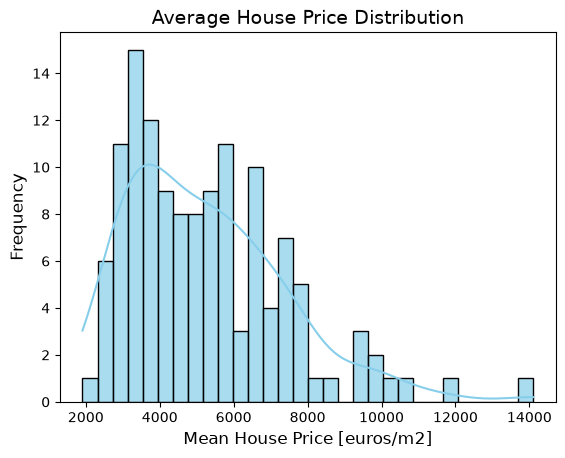

In [20]:
# Histogram of average house prices

# Create the plot
sns.histplot(df["mean_average_price_euros_per_m2"], kde=True, bins=30, color="skyblue", edgecolor="black", alpha=0.7)

# Add titles and labels
plt.title("Average House Price Distribution", fontsize=14)
plt.xlabel("Mean House Price [euros/m2]", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Show the plot
plt.show()

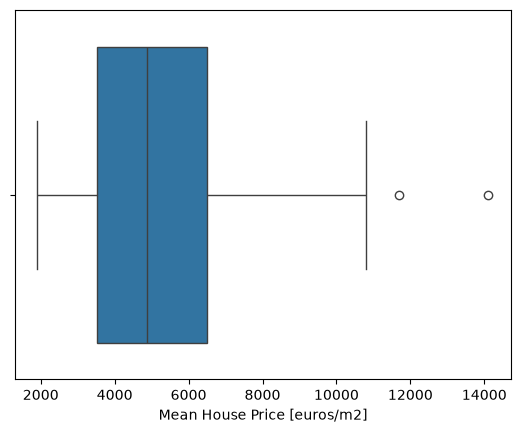

In [21]:
# Boxplot of average house price

# Create the plot with label
sns.boxplot(x=df["mean_average_price_euros_per_m2"]).set(xlabel='Mean House Price [euros/m2]')
# Show the plot
plt.show()

### Observations 

The summary statistics showed that the mean average housing price across Madrid's 130 neighbourhoods was approximately €5,260 per m². The standard deviation of €2,162 per m² indicated considerable variation in housing prices between neighbourhoods.

The histogram showed that the distribution of housing prices was positively (right) skewed, with most neighbourhoods clustered around lower to mid-range prices and a smaller number of neighbourhoods exhibited substantially higher prices. This is supported by the box plot, which identified two high-price outliers above the upper quartile and no low-price outliers.

### Plot select socioeconomic indicators against average house price

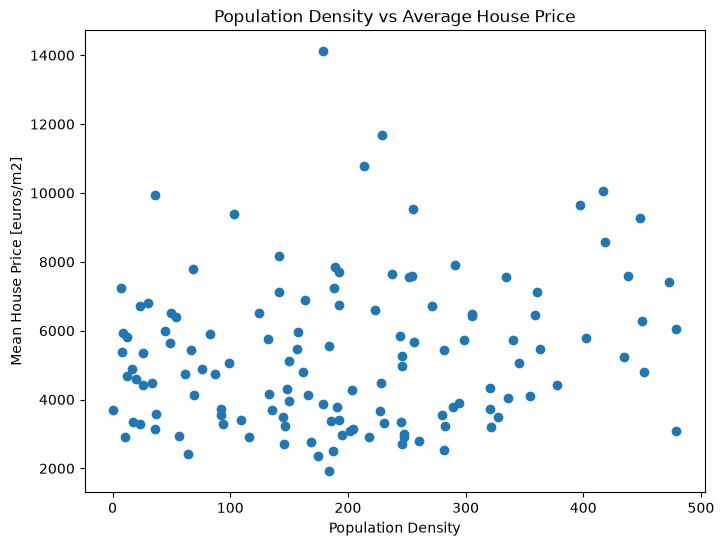

In [22]:
# Scatterplot of population density against average house price 

# Create the plot
plt.figure(figsize=(8,6))
plt.scatter(df["population_density"],df["mean_average_price_euros_per_m2"])

# Add titles and labels
plt.title("Population Density vs Average House Price")
plt.xlabel("Population Density") 
plt.ylabel("Mean House Price [euros/m2]")

# Show the plot
plt.show()

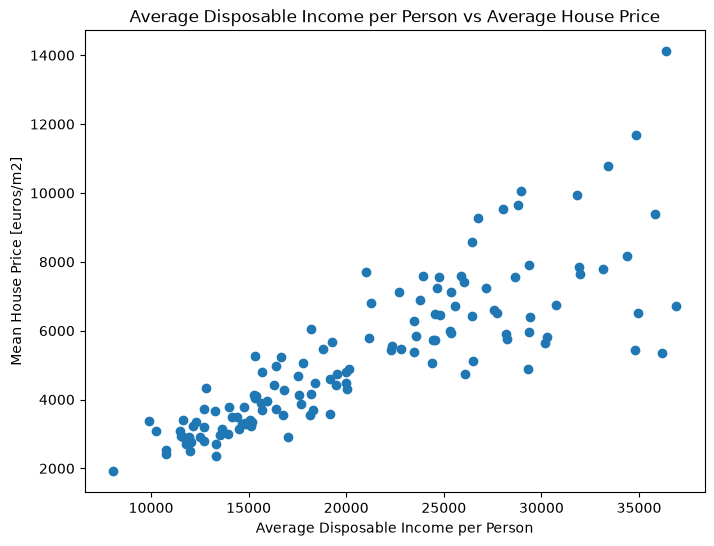

In [23]:
# Scatterplot of average disposable income per person against average house price 

# Create the plot
plt.figure(figsize=(8,6))
plt.scatter(df["average_disposable_income_per_person"],df["mean_average_price_euros_per_m2"]) 

# Add titles and labels
plt.title("Average Disposable Income per Person vs Average House Price")
plt.xlabel("Average Disposable Income per Person") 
plt.ylabel("Mean House Price [euros/m2]") 

# Show the plot
plt.show()

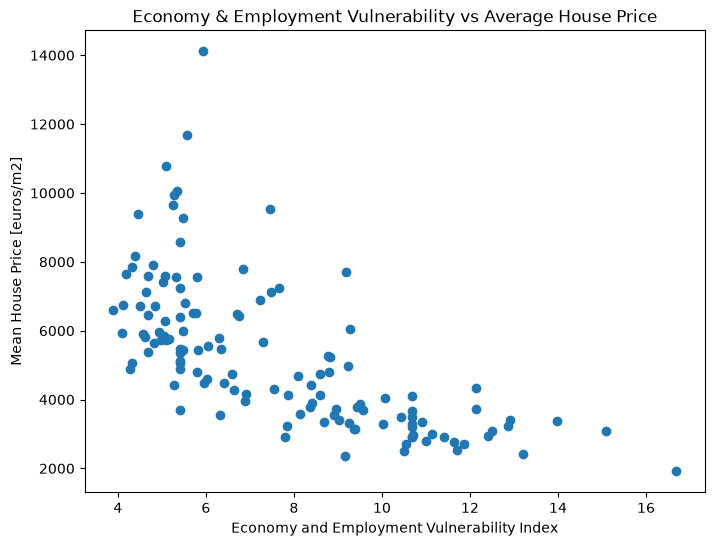

In [24]:
# Scatterplot of 'economy and employment vulnerability' against Average House Price 

# Create the plot
plt.figure(figsize=(8,6))
plt.scatter(df["economy_and_employment_vulnerability_index"],df["mean_average_price_euros_per_m2"]) 

# Add titles and labels
plt.title("Economy & Employment Vulnerability vs Average House Price")
plt.xlabel("Economy and Employment Vulnerability Index") 
plt.ylabel("Mean House Price [euros/m2]") 

# Show the plot
plt.show()

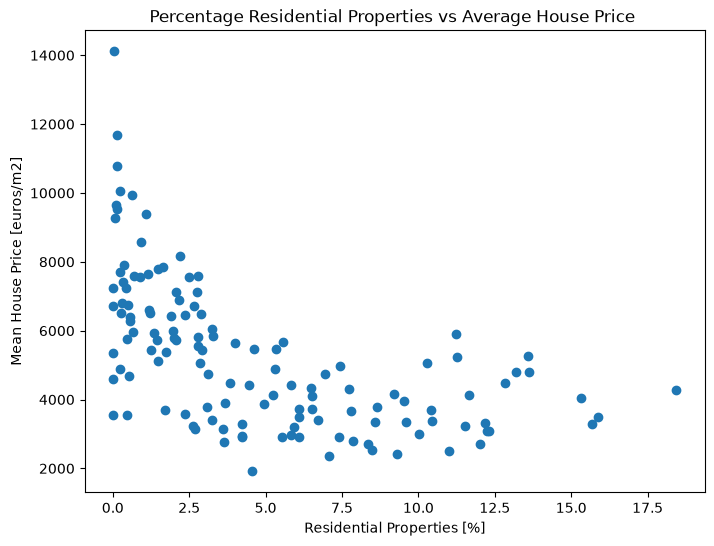

In [25]:
# Scatterplot of % Residential Properties vs Average House Price 

# Create the plot
plt.figure(figsize=(8,6))
plt.scatter(df["percentage_residential_properties"],df["mean_average_price_euros_per_m2"]) 

# Add titles and labels
plt.title("Percentage Residential Properties vs Average House Price ")
plt.xlabel("Residential Properties [%]") 
plt.ylabel("Mean House Price [euros/m2]")

# Show the plot
plt.show()


In [26]:
# Create correlation matrix of socioeconomic indicators against average house price only
corr_matrix=df.corr(numeric_only=True)[["mean_average_price_euros_per_m2"]].sort_values(by="mean_average_price_euros_per_m2", ascending=False)

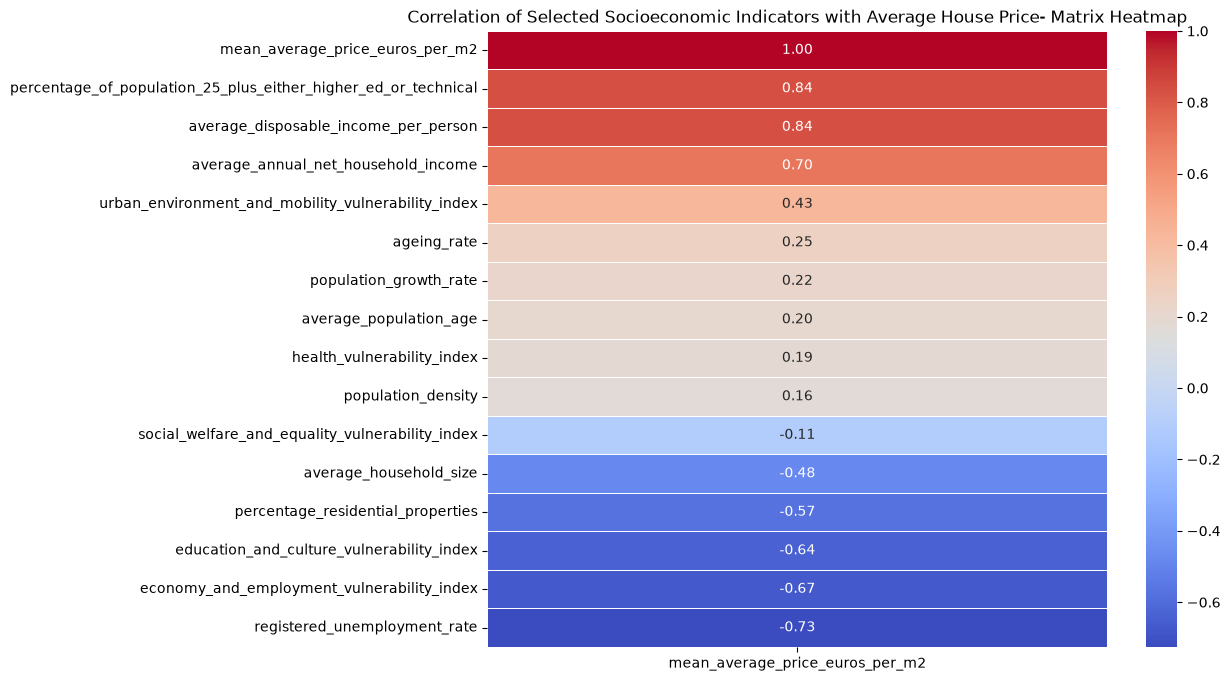

In [27]:
# Create the plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add title
plt.title('Correlation of Selected Socioeconomic Indicators with Average House Price- Matrix Heatmap')

# Show the plot
plt.show()

### Observations
The correlation matrix and selected scatter plots showed a range of positive and negative relationships between the socioeconomic indicators and average housing price. The percentage of the 25+ population with a higher education or technical qualification and average disposable income per person exhibited the strongest positive correlations with average housing price (r=0.84,r=0.84). In contrast, the registered unemployment rate showed a strong negative correlation(r=-0.73).

Several indicators showed little or no linear relationship with average housing price. For example, population density had a very weak positive correlation (r=0.11), which is reflected in its scatter plot (above) where no clear linear trend is evident.

The variation in correlation strength suggests that some features are likely to be more informative predictors than others. In future iterations, feature selection could be refined by focusing on the indicators with the strongest relationships to average housing price or by applying formal feature selection techniques to pick the most useful data features.

## 5. Data Preparation

In [28]:
# Prepare the Feature and Target Variable
X = df[['average_population_age','population_density','ageing_rate','average_disposable_income_per_person','average_annual_net_household_income','average_household_size','registered_unemployment_rate','population_growth_rate','social_welfare_and_equality_vulnerability_index','economy_and_employment_vulnerability_index','education_and_culture_vulnerability_index','urban_environment_and_mobility_vulnerability_index','health_vulnerability_index','percentage_residential_properties','percentage_of_population_25_plus_either_higher_ed_or_technical']]
y = df [['mean_average_price_euros_per_m2']]

## 6. Train-test Split

In [29]:
# Split dataset (80%- train /20%- test)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42
)

### Observations
The dataset was split 80% training data and 20% test data randomly, a random state was chosen to ensure reproducibility, so that the same sequence of random numbers will be used each time the code is run.

## 7. Model Development

In [30]:
# Linear regression model is selected as the target is numerical

model = LinearRegression()

In [31]:
# Train the model on data 
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 15)","[[-87.86, 0.96, 6.37,..., 60.38, -9.41, -5.06]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['average_population_age','population_density','ageing_rate',..., 'health_vulnerability_index','percentage_residential_properties', 'percentage_of_population_25_plus_either_higher_ed_or_technical']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[10696.98]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)


## 8. Predictions and Interpretations

In [32]:
# Predict y values for the x values from the test data 

y_pred = model.predict(X_test)

In [33]:
# Create a comparison table of actual and predicted average house prices

comparison = pd.DataFrame({
    "Actual": y_test.squeeze(), 
    "Predicted": y_pred.flatten()
})

In [34]:
# View first 10 values via the comparison table

comparison.head(10)

,Actual,Predicted
55,9638.66,8371.601408
40,5426.01,5680.703434
19,3143.01,3051.062284
31,7558.90,6564.784340
115,5274.19,4066.485417
56,6722.25,6400.296033
69,2807.40,2612.560491
105,2755.18,2756.482197
81,6286.22,6445.630175
26,3355.20,2870.506622


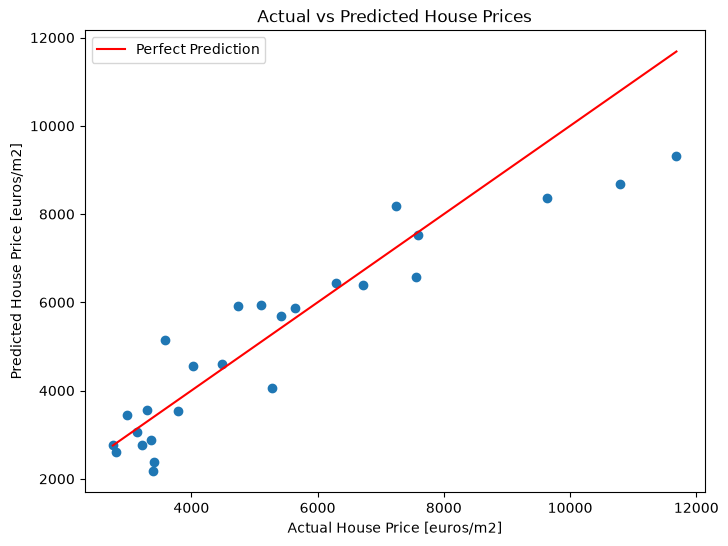

In [35]:
# Scatterplot of Actual vs Predicted House Prices

# Create the plot
plt.figure(figsize=(8,6))
plt.scatter(comparison["Actual"],comparison["Predicted"])
sns.lineplot(x=[comparison["Actual"].min(), comparison["Actual"].max()], y=[comparison["Actual"].min(), comparison["Actual"].max()], color='red', label='Perfect Prediction')


# Add titles and labels
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.xlabel("Actual House Price [euros/m2]") 
plt.ylabel("Predicted House Price [euros/m2]")

# Show the plot
plt.show()

In [36]:
# Confirm datatypes
comparison.dtypes

Actual       float64
Predicted    float64
dtype: object

In [37]:
# Obtain % error between actual and predicted values
comparison_calculation= comparison.copy()

comparison_calculation['Percentage Difference']=(comparison_calculation['Actual']- comparison_calculation['Predicted'])/comparison_calculation['Actual']*100


In [38]:
# View all rows of the updated the comparison table

comparison_calculation= comparison_calculation.sort_values(by='Percentage Difference')

comparison_calculation

,Actual,Predicted,Percentage Difference
100,3580.16,5139.697086,-43.560542
45,4735.53,5928.384367,-25.189459
64,5106.44,5937.068140,-16.266286
84,2985.52,3442.344488,-15.301337
97,4033.30,4552.307126,-12.868052
36,7246.75,8175.740038,-12.819402
18,3291.57,3552.604799,-7.930404
40,5426.01,5680.703434,-4.693936
11,5644.82,5876.518353,-4.104619
120,4484.04,4602.546644,-2.642854


In [39]:
# Dimension of comparison_calculation 
comparison_calculation.shape

(26, 3)

In [40]:
# Number of rows within 5%
comparison_calculation['Percentage Difference'].between(-5, 5).sum()

np.int64(8)

In [41]:
# Number of rows within 15%
comparison_calculation['Percentage Difference'].between(-15, 15).sum()

np.int64(17)

In [42]:
# Number of rows within 20%
comparison_calculation['Percentage Difference'].between(-20, 20).sum()

np.int64(20)

### Observations

Inspection of the predicted average house prices showed that approximately 30% of predictions were within 5% of the actual values, 65% were within 15%, and 77% were within 20%. While the model performed well for many neighbourhoods, several predictions showed larger errors which suggests room for improvement. The scatter plot showed that the model likely predicted values more accurately for values that were closer to the middle of the dataset than at the higher end. 

Future iterations of the model could aim to reduce these larger prediction errors while increasing the proportion of predictions that fall closer to the actual house prices.

## 9. Model Evaluation

In [43]:
# Calculate Mean Absolute Error (MAE)

mae = mean_absolute_error(y_test, y_pred) 
print("Mean Absolute Error:", mae)

Mean Absolute Error: 713.4225586390205


In [44]:
# Calculate Mean Squared Error (MSE)

mse = mean_squared_error(y_test, y_pred) 
print("Mean Squared Error:", mse)

Mean Squared Error: 897950.1376813232


In [45]:
# Calculate Root Mean Squared Error (RMSE-Prediction error)

mse = mean_squared_error(y_test, y_pred) 
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 947.6023098754683


In [46]:
# Calculate R2 Score (Coefficient of determination)
r2 = r2_score(y_test, y_pred) 
print("R2 Score:", r2)

# R2 Score: 0.8513274498959232

R2 Score: 0.851327449895924


In [47]:
# Dsiplay statistical information for mean house price
df_2=madrid_2025['mean_average_price_euros_per_m2']
df_2.describe()

count      130.000000
mean      5260.168615
std       2162.151401
min       1909.600000
25%       3513.622500
50%       4884.510000
75%       6500.757500
max      14108.830000
Name: mean_average_price_euros_per_m2, dtype: float64

### Observations

#### Mean Absolute Error (MAE)
The model produced a Mean Absolute Error (MAE) of 713 euros/m². This indicates that on average the predicted housing price differed from the actual value by 713 euros/m², equivalent to approximately 14% of the mean house price. This suggests that the model provided reasonably accurate predictions for average neighbourhood housing prices.

#### Mean Squared Error (MSE)
The model produced a Mean Squared Error (MSE) of 897,950 (euros/m²)². As this metric squares the prediction errors, larger errors have a much greater influence on the final value. Compared with the squared MAE (approximately 508,000), the substantially higher MSE suggests that while many predictions are reasonably accurate, a small number of neighbourhoods had considerably larger prediction errors. Reducing these larger errors would improve the overall performance of the model.

#### Root Mean Squared Error (RMSE) 
The model produced a Root Mean Squared Error (RMSE) of 948 euros/m², equivalent to approximately 18% of the mean house price. As RMSE places greater emphasis on larger prediction errors than MAE, the higher value suggests that a small number of neighbourhoods were predicted less accurately. Nevertheless, the overall prediction error remains reasonable and could be reduced through further refinement of the model.

#### R² score
The model produced an R² score of 0.85, indicating that approximately 85.13% of the variation in average neighbourhood house prices is explained by the selected socioeconomic indicators. This suggests that the model has learned a strong relationship between the input features and the target variable.The remaining 14.87% of the variation is not explained by the model and may be attributable to factors not included in the dataset.



## 10. Improvements

### Overal Model Evaluation

Overall, the results suggested that the model performed strongly while still leaving scope for improvement. Future work should focus on reducing the larger prediction errors and strengthening the relationship learned between the selected socioeconomic indicators and average neighbourhood house prices.

#### Limitations

The model has several limitations. It uses only 130 neighbourhood observations from a single year, which limits the amount of data available for training and testing. The 15 socioeconomic features were selected through exploration of the available indicators rather than a literature review, meaning other relevant factors may have been excluded. Additionally, the model identifies relationships between socioeconomic indicators and housing prices but does not establish causation.

#### Improvements

Potential improvements include:

- Outlier treatment:
The box plots indicated at least two high-value outliers. Investigating whether these observations are genuine or disproportionately influencing the model could improve predictive performance.

- Alternative machine learning models:
This project used a Linear Regression model. Future work could evaluate alternative regression models to determine whether they better capture a potentially non-linear or more complex relationships between socioeconomic indicators and house prices.

- Feature scaling:
The selected features were measured on different scales, including percentages, index values and absolute values. Future work could investigate whether scaling or standardisation could benefit model performance.

- Feature engineering:
Although two engineered features were included, further feature engineering may produce more informative variables. Creating additional derived features could help the model capture more complex relationships within the data.

- Feature selection:
The raw dataset contains many additional socioeconomic indicators. Literature review and exploratory analysis could help identify variables with stronger theoretical or statistical relationships with housing prices. Likewise, variables exhibiting consistently weak correlations could be removed where appropriate.

- Optimising the number of features:
The model was developed using 15 socioeconomic indicators and only 130 observations. Future work could investigate the optimal number of features to improve predictive performance while reducing the risk of overfitting.

- Incorporating historical data:
This project focused exclusively on 2025 data. Including observations from previous years may enable the model to capture longer-term socioeconomic trends and improve its ability to predict future neighbourhood house prices.